### Building a recommendation system


Transactions can be represented as both senders and receivers, in a U and V tables.  so U and V embeddings would collapse. You'd need to either:
1. Treat sender/receiver as two separate roles (two embedding tables, same nodes)
2. Use a single embedding per transaction and model interactions as inner products

Option 2 is essentially LightGCN — which is a GNN but derived from MF
thinking.

MF formulation:

V_flow ≈ U_sender × U_receiver^T    (adjacency reconstruction)

+ supervised head:
class_i = sigmoid(w^T · U_i)        (predict label from embedding)

Loss = α · ||V_flow - U U^T||²  +  β · BCE(y_known, ŷ_known)

Train on known labels (class 0/1), predict for class 2. This is
semi-supervised CF with graph structure as the interaction signal.
Joint loss:
  L = α · L_link  +  β · L_class

  L_link  = BCE(A[i,j], σ(uᵢ · uⱼ))   — adjacency reconstruction (CF signal)
  L_class = BCE(yᵢ,     σ(w^T uᵢ))     — label prediction (supervised signal)

### Two variants
  Option 1 — Two roles: U_sender, U_receiver (separate tables, same nodes)
              handles directed graph naturally; combined embedding = (U_s + U_r)/2
  Option 2 — Single embedding U: symmetric, simpler, equivalent to LightGCN-0
              U_sender = U_receiver = U

### Split
  Train supervision: class 0/1 labels from t ≤ 35
  Val:  t = 36..40
  Test: t = 41..49  (predict class for all, evaluate on class 0/1 only)



## Semi-Supervised CF via Matrix Factorization

This is the first model that uses known labels (class 0/1) as explicit ratings — the true CF formulation:

    - "Users"   = transactions
    - "Items"   = transactions (same entity, interaction = flow)
    - "Ratings" = class label (0=licit, 1=illicit) — sparse, ~15% known
    - "Missing" = class 2 (unknown) — to be predicted

The flow graph provides the interaction structure for embedding learning.
  Class labels provide supervision for the prediction head.


# Imports

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

from sklearn.decomposition import  TruncatedSVD, PCA
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import f1_score, precision_score, accuracy_score, recall_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression                                       

from scipy.sparse import csr_matrix                                                       


# Data loading

In [2]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


In [3]:
cols = ['txId','time_step']


local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols

In [4]:
feature_cols = local_cols + agg_cols

In [5]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [6]:
# map classes: licit - 0; illicit- 1;  unknown -2
class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True).astype(int)
classes['class'].value_counts()

class
2    157205
0     42019
1      4545
Name: count, dtype: int64

In [7]:
df = pd.merge(features, classes, on='txId')

# implementation with SKLEARN: TSVD

Step 1: TruncatedSVD on the sparse adjacency matrix → node embeddings (captures graph     
  structure)                                                                                
  Step 2: LogisticRegression on known labels using those embeddings → predicts unknown      
  classes  

## Pipeline Definition

In [8]:
def build_adjacency(df, edges, symmetric=True):
    # the adj. represents the links between the transactions. each transaction is both a sender and receiver.
    node_to_idx = {nid: i for i, nid in enumerate(df['txId'].values)}
    n = len(node_to_idx)
    mask = edges['txId1'].isin(node_to_idx) & edges['txId2'].isin(node_to_idx)            
    rel  = edges[mask]
    src  = rel['txId1'].map(node_to_idx).values
    dst  = rel['txId2'].map(node_to_idx).values
    data = np.ones(len(src))
    A    = csr_matrix((data, (src, dst)), shape=(n, n))     # csr to compress the sparse data
    if symmetric:
        A = A + A.T         # undirected — single embedding
    return A, node_to_idx

  

In [9]:
def mf_cf_sklearn(df, edges, feature_cols,
                    train_ts=range(1,36), val_ts=range(36,41),
                    test_ts=range(41,50), k=32,
                    use_features=True):

    node_to_idx = {nid: i for i, nid in enumerate(df['txId'].values)}

    # Step 1: graph embeddings via SVD of adjacency
    A, node_to_idx = build_adjacency(df, edges, symmetric=True)
    svd = TruncatedSVD(n_components=k, random_state=90)
    G   = svd.fit_transform(A)      # (n_nodes × k) — graph embedding

    # Step 2: node features (optional)
    X = df[feature_cols].values.astype(np.float32)
    train_mask = (df['class'] == 0) & (df['time_step'].isin(train_ts))
    feat_scaler = RobustScaler().fit(X[train_mask.values])
    X_s = feat_scaler.transform(X)

    # combine graph embedding + node features
    if use_features:
        emb = np.hstack([G, X_s])
    else:
        emb = G
    # Step 3: train logistic regression on known labels
    labeled_mask = (df['class'] < 2) & (df['time_step'].isin(train_ts))
    X_labeled = emb[labeled_mask.values]
    y_labeled = df.loc[labeled_mask, 'class'].values.astype(int)
                
    clf = LogisticRegression(max_iter=10000, solver='lbfgs', random_state=90)
    clf.fit(X_labeled, y_labeled) 
    
    def evaluate(ts, label):
        mask    = df['time_step'].isin(ts) & (df['class'] < 2)
        X_eval  = emb[mask.values]
        y_eval  = df.loc[mask, 'class'].values.astype(float)
        scores  = clf.predict_proba(X_eval)[:, 1].astype(float)
        preds  = clf.predict(X_eval)

        auc = roc_auc_score(y_eval, scores)                                                   
        ap  = average_precision_score(y_eval, scores)                                         
        f1  = f1_score(y_eval, preds)                                                         
        pre = precision_score(y_eval, preds)                                                  
        recall = recall_score(y_eval, preds)                                                  
        acc = accuracy_score(y_eval, preds)                                                   
                                                                                            
        print(f'{label} — ROC-AUC: {auc:.4f} | AP: {ap:.4f} | 'f'F1: {f1:.4f} | Precision: {pre:.4f} | Recall: {recall:.4f} | Accuracy: {acc:.4f}')                   
        return scores, y_eval
        

    val_scores,  val_y  = evaluate(val_ts,  'Val ')
    test_scores, test_y = evaluate(test_ts, 'Test')
    return clf, svd, emb, val_scores, test_scores

In [10]:
clf, svd, emb, val_scores, test_scores = mf_cf_sklearn(
      df, edges, feature_cols,  
      train_ts=range(1,36), val_ts=range(36,41), test_ts=range(41,50),                      
      k=64, use_features=True
  ) 

/home/tiggi/Documents/IU_projects/bitcoin_rec/fraud_aml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 6365 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Val  — ROC-AUC: 0.9446 | AP: 0.6618 | F1: 0.5668 | Precision: 0.4410 | Recall: 0.7931 | Accuracy: 0.9147
Test — ROC-AUC: 0.8468 | AP: 0.2938 | F1: 0.3373 | Precision: 0.2350 | Recall: 0.5973 | Accuracy: 0.8767


In [23]:
def plot_embeddings(emb, df, sample_n=5000):

    labeled = df['class'] < 2
    emb_lab = emb[labeled.values]
    y_lab   = df.loc[labeled, 'class'].values

    # sample for readability
    idx = np.random.choice(len(emb_lab), min(sample_n, len(emb_lab)), replace=False)

    pca    = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb_lab[idx])

    fig, ax = plt.subplots(figsize=(10, 8))
    colors  = {0: 'steelblue', 1: 'crimson'}

    # Define primary plot limits to calculate bounding box logic
    x_min_glob, x_max_glob = np.percentile(emb_2d[:, 0], [1, 99])
    y_min_glob, y_max_glob = np.percentile(emb_2d[:, 1], [1, 99])
    x_pad = (x_max_glob - x_min_glob) * 0.05
    y_pad = (y_max_glob - y_min_glob) * 0.05

    ax.set_xlim(x_min_glob - x_pad, x_max_glob + x_pad)
    ax.set_ylim(y_min_glob - y_pad, y_max_glob + y_pad)

    # focus square for the top left part:
    ax_ins = ax.inset_axes([0.55, 0.1, 0.4, 0.4])

    # plot
    for cls, label in [(0, 'Licit'), (1, 'Illicit')]:
        mask = y_lab[idx] == cls
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=colors[cls], alpha=0.4, s=10, label=label)
        
        # plot inset - 
        ax_ins.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                        c=colors[cls], alpha=0.6, s=12, label=label)
        
    # set zoom boundaries
    x_zoom_min = x_min_glob - x_pad
    x_zoom_max = x_min_glob + (x_max_glob - x_min_glob) * 0.25 # Adjust width slice as needed
    y_zoom_min = y_max_glob - (y_max_glob - y_min_glob) * 0.55 # Adjust height slice as needed
    y_zoom_max = y_max_glob + y_pad

    ax_ins.set_xlim(x_zoom_min, x_zoom_max)
    ax_ins.set_ylim(y_zoom_min, y_zoom_max)
    
    # Clean up inset ticks so they don't overlap or look messy
    ax_ins.xaxis.get_major_locator().set_params(nbins=4)
    ax_ins.yaxis.get_major_locator().set_params(nbins=4)
    ax_ins.set_title("Dense Cluster Zoom (Top Left)", fontsize=9, pad=4)


    ax.set_title(f'Node embeddings — PCA 2D\n'
                f'(explained variance: {pca.explained_variance_ratio_.sum():.2%})')
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.legend(loc="upper right")
    
    # x_min, x_max = np.percentile(emb_2d[:, 0], [1, 99])
    # y_min, y_max = np.percentile(emb_2d[:, 1], [1, 99])
    # x_pad = (x_max - x_min) * 0.05
    # y_pad = (y_max - y_min) * 0.05
    # ax.set_xlim(x_min - x_pad, x_max + x_pad)
    # ax.set_ylim(y_min - y_pad, y_max + y_pad)

    plt.tight_layout()
    plt.savefig('pca.png')
    plt.show()



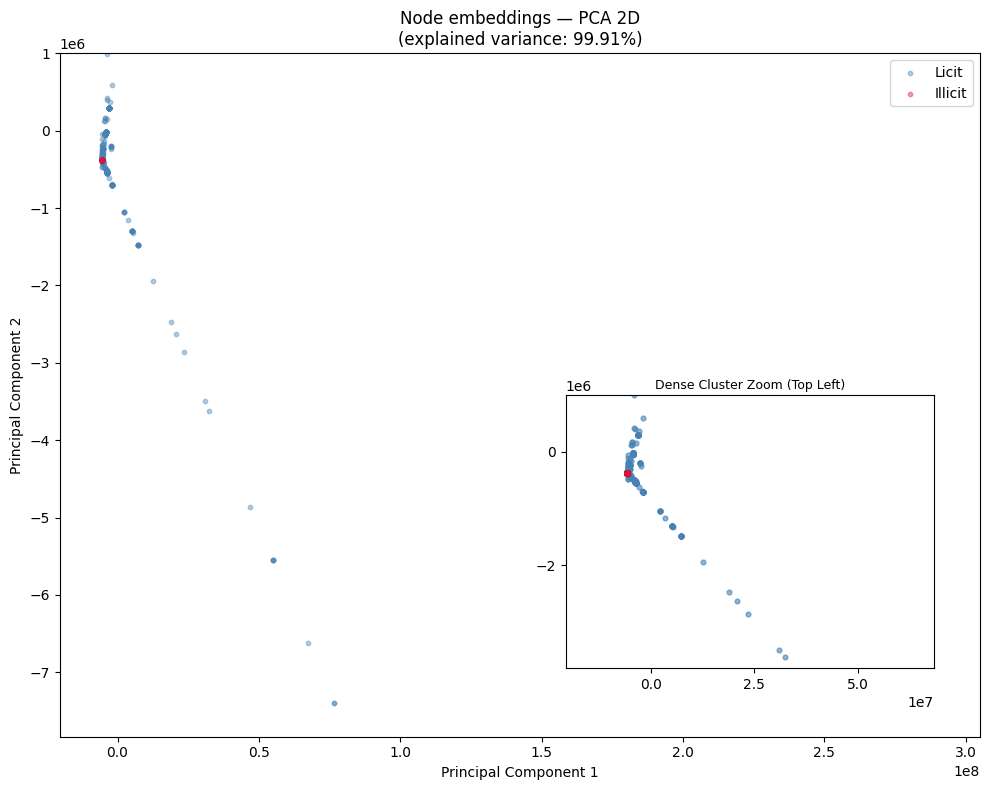

In [24]:
plot_embeddings(emb, df)


# single vs. double table

**Variant 1 ( symmetric - also above with TSVD):**
`TruncatedSVD` on `A + Aᵀ` collapses the directed graph into undirected before
factorization. Each transaction gets *one* embedding that mixes both its sender and
receiver behavior. Directionality is lost.

**Variant 2 (two-role — directed):**
The Bitcoin flow graph is inherently directed — money flows one way. We factorize the
directed adjacency `A` via SVD:

    A ≈ U Σ Vᵀ

- `U_sender` — left singular vectors: how this node behaves *as a sender*
- `V_receiver` — right singular vectors: how this node behaves *as a receiver*

Both are concatenated per node: `emb_i = [U_i ‖ V_i]` → 2k dimensions.

This lets the classifier distinguish nodes that are pure senders vs. pure receivers vs.
balanced — a potential fraud signal that symmetrizing destroys.

# Single and Double table with Pytorch

### PyTorch Joint MF: Double-Table and Single-Table

  Both variants share the same architecture and training loop.
  The only difference is whether sender and receiver embeddings are the same table.

  **Double-table** (`shared_table=False`):
      E_sender  (n × k) — how this node behaves as sender
      E_receiver (n × k) — how this node behaves as receiver
      Link score: σ(E_sender[i] · E_receiver[j])
      Classifier input: [E_sender_i ‖ E_receiver_i ‖ features]

  **Single-table** (`shared_table=True`):
      E (n × k) — one embedding, E_sender = E_receiver = E
      Equivalent to symmetric MF / LightGCN-0

  Joint loss:
      L = α · L_link  +  β · L_class                        
      L_link  = BCE on positive edges + sampled negatives   # loss on learning the graph structure
      L_class = BCE on known labels (class 0/1 from train timesteps)    # classification loss


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [14]:
class MF_CF(nn.Module):
    def __init__(self, n_nodes, n_features, k=32, shared_table=False, hidden_dim=64):
        super().__init__()
        self.E_sender = nn.Embedding(n_nodes, k)
        self.E_receiver = self.E_sender if shared_table else nn.Embedding(n_nodes, k)

        self.classifier = nn.Sequential(
            nn.Linear(2 * k + n_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        nn.init.xavier_uniform_(self.E_sender.weight)   # values from X.uniform distribution to initialize weights - so the variance doesnt cause vanishing/exploding gradients
        
        if not shared_table:
            self.E_receiver = nn.Embedding(n_nodes, k)      # create separate if not shared
            nn.init.xavier_uniform_(self.E_receiver.weight)
        else:
            self.E_receiver = self.E_sender

    def link_score(self, src, dst):
        return (self.E_sender(src) * self.E_receiver(dst)).sum(dim=1)       # @ scalar is the raw link score - compatibility of se_i and re_j.("immitates connections") 

    def classify(self, node_ids, features):
        e_s = self.E_sender(node_ids)
        e_r = self.E_receiver(node_ids)
        return self.classifier(torch.cat([e_s, e_r, features], dim=1)).squeeze(1)


In [15]:
def sample_negatives(n_nodes, n_pos, device):         # n_nodes = nr of Edges.
      """
      randomly sampled node pairs with no edge between them. The model should score these LOW (label= 0).
      """
      return (torch.randint(0, n_nodes, (n_pos,), device=device),
              torch.randint(0, n_nodes, (n_pos,), device=device))

The contrast between real and fake edges is what forces the embeddings to encode graph structure.
pos_scores  → real edges    → target score 1
neg_scores  → random pairs  → target score 0                                                                           
   
Both are concatenated and fed into one BCE loss

In [16]:
def train_mf_cf(model, optimizer, src, dst,
                  labeled_idx, labeled_feats, labeled_y, pos_weight, n_epochs,
                  alpha=1.0, beta=1.0,  device='cpu',
                  val_idx=None, val_feats=None, val_y_np=None, eval_every=20):
    
    # collect metrics
    train_losses, link_losses, class_losses = [], [], []
    val_aucs, val_epochs = [], []

    
    model.train()
    for epoch in range(n_epochs):
        optimizer.zero_grad()

        # link loss: positive edges + random negatives
        pos_scores = model.link_score(src, dst)       # Edges thatexist in the training graph
        neg_src, neg_dst = sample_negatives(model.E_sender.num_embeddings, len(src), device)
        neg_scores = model.link_score(neg_src, neg_dst)

        link_scores  = torch.cat([pos_scores, neg_scores])
        link_targets = torch.cat([torch.ones(len(src), device=device),
                                torch.zeros(len(src), device=device)])
        L_link = F.binary_cross_entropy_with_logits(link_scores, link_targets)
        
        # classification loss on known labels: 
        ## incl. weight of class imbalance in training set: 
        L_class = F.binary_cross_entropy_with_logits(
              model.classify(labeled_idx, labeled_feats), labeled_y,                                               
              pos_weight=pos_weight)                                     


        loss = alpha * L_link + beta * L_class
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        link_losses.append(L_link.item())
        class_losses.append(L_class.item())

        if val_idx is not None and (epoch + 1) % eval_every == 0:
            model.eval()
            with torch.no_grad():
                val_scores = torch.sigmoid(model.classify(val_idx, val_feats)).cpu().numpy()
            val_auc = roc_auc_score(val_y_np, val_scores)
            val_aucs.append(val_auc)
            val_epochs.append(epoch + 1)
            model.train()


        if (epoch + 1) % 20 == 0:
            print(f'  Epoch {epoch+1:>3}: loss={loss.item():.4f} '
                f'(link={L_link.item():.4f}, class={L_class.item():.4f})')
    return train_losses, link_losses, class_losses, val_aucs, val_epochs

In [17]:
def plot_training_curves(train_losses, link_losses, class_losses, val_aucs, val_epochs):
      epochs = range(1, len(train_losses) + 1)

      fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

      # loss curves
      ax1.plot(epochs, train_losses, label='Total loss',  color='black',    linewidth=1.5)
      ax1.plot(epochs, link_losses,  label='Link loss',   color='steelblue', linewidth=1,
  linestyle='--')
      ax1.plot(epochs, class_losses, label='Class loss',  color='crimson',   linewidth=1,
  linestyle='--')
      ax1.set_xlabel('Epoch')
      ax1.set_ylabel('Loss')
      ax1.set_title('Training Loss')
      ax1.legend()

      # val AUC
      ax2.plot(val_epochs, val_aucs, color='steelblue', linewidth=1.5, marker='o',
  markersize=3)
      ax2.set_xlabel('Epoch')
      ax2.set_ylabel('ROC-AUC')
      ax2.set_title('Validation AUC during Training')
      ax2.set_ylim(0.5, 1.0)

      plt.tight_layout()
      plt.show()


In [18]:
@torch.no_grad()
def evaluate_mf_cf(model, df, node_to_idx, X_s, eval_ts, label, device='cpu'):
    model.eval()
    mask = df['time_step'].isin(eval_ts) & (df['class'] < 2)
    eval_df = df[mask]

    idx = torch.tensor([node_to_idx[n] for n in eval_df['txId'].values],
                dtype=torch.long, device=device)
    feats = torch.tensor(X_s[mask.values], dtype=torch.float32, device=device)
    y = eval_df['class'].values.astype(int)

    scores = torch.sigmoid(model.classify(idx, feats)).cpu().numpy()
    preds  = (scores > 0.5).astype(int)

    auc = roc_auc_score(y, scores)
    ap  = average_precision_score(y, scores)
    f1  = f1_score(y, preds)
    pre = precision_score(y, preds)
    rec = recall_score(y, preds)
    acc = accuracy_score(y, preds)

    print(f'{label} — ROC-AUC: {auc:.4f} | AP: {ap:.4f} | F1: {f1:.4f} | '
        f'Precision: {pre:.4f} | Recall: {rec:.4f} | Accuracy: {acc:.4f}')
    
    return scores, y

In [ ]:
# Plot selection of classification threshold based on val scores and labels, for the best results
def plot_threshold_selection(val_scores, val_y, best_thresh):
      precision_c, recall_c, thresholds = precision_recall_curve(val_y, val_scores)
      f1_c = 2 * precision_c[:-1] * recall_c[:-1] / (precision_c[:-1] + recall_c[:-1] + 1e-8)
      best_idx = np.argmin(np.abs(thresholds - best_thresh))

      fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

      # PR curve with chosen threshold marked
      ax1.plot(recall_c, precision_c, color='steelblue', linewidth=1.5)
      ax1.scatter(recall_c[best_idx], precision_c[best_idx],
                  color='crimson', zorder=5, s=80, label=f'thresh={best_thresh:.2f}')
      ax1.set_xlabel('Recall')
      ax1.set_ylabel('Precision')
      ax1.set_title('Precision-Recall Curve (Val)')
      ax1.legend()

      # F1 vs threshold
      ax2.plot(thresholds, f1_c, color='steelblue', linewidth=1.5)
      ax2.axvline(best_thresh, color='crimson', linestyle='--', label=f'best={best_thresh:.2f}')
      ax2.set_xlabel('Threshold')
      ax2.set_ylabel('F1')
      ax2.set_title('F1 vs Threshold (Val)')
      ax2.legend()

      plt.tight_layout()
      plt.show()


In [ ]:
# RecSys metrics function:
from sklearn.metrics import ndcg_score  # Compute Normalized Discounted Cumulative Gain.

# this ranking metric returns a high value if true labels are ranked high by y_scores. 
# used to evaluate the quality of the ranking of transactions by their predicted fraud score.
def rec_metrics_at_k(y_true, scores, ks=(50, 100, 200)):
    order = np.argsort(scores)[::-1]
    y_sorted = y_true[order]

    print(f"{'k':<8} {'P@k':<10} {'R@k':<10} {'NDCG@k':<10}")
    print('-' * 38)
    for k in ks:
        top_k  = y_sorted[:k]
        p_at_k = top_k.sum() / k
        r_at_k = top_k.sum() / y_true.sum()
        ndcg   = ndcg_score([y_true], [scores], k=k)
        print(f"{k:<8} {p_at_k:<10.4f} {r_at_k:<10.4f} {ndcg:<10.4f}")


In [ ]:
from xml.parsers.expat import model


def mf_cf_torch(df, edges, feature_cols, train_ts=range(1, 36), val_ts=range(36, 41), test_ts=range(41, 50),
                  k=32, shared_table=False, hidden_dim=64,
                  alpha=1.0, beta=1.0, n_epochs=200, lr=1e-3, pos_weight: bool=False):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    node_to_idx = {nid: i for i, nid in enumerate(df['txId'].values)}
    n_nodes = len(node_to_idx)

    # edges restricted to training timesteps
    train_txids = set(df[df['time_step'].isin(train_ts)]['txId'].values)
    train_edges = edges[edges['txId1'].isin(train_txids) & edges['txId2'].isin(train_txids)]
    src = torch.tensor([node_to_idx[x] for x in train_edges['txId1'].values],
                        dtype=torch.long, device=device)
    dst = torch.tensor([node_to_idx[x] for x in train_edges['txId2'].values],
                        dtype=torch.long, device=device)

    # node features — fit scaler on licit train nodes only
    X = df[feature_cols].values.astype(np.float32)
    licit_train = (df['class'] == 0) & (df['time_step'].isin(train_ts))
    X_s = RobustScaler().fit(X[licit_train.values]).transform(X)
    n_features = X_s.shape[1]

    # labeled nodes for classification loss
    labeled_mask = (df['class'] < 2) & (df['time_step'].isin(train_ts))
    labeled_df = df[labeled_mask]
    labeled_idx = torch.tensor([node_to_idx[n] for n in labeled_df['txId'].values], dtype=torch.long, device=device)
    labeled_feats = torch.tensor(X_s[labeled_mask.values], dtype=torch.float32, device=device)
    labeled_y = torch.tensor(labeled_df['class'].values.astype(np.float32), device=device)

    # compute weight of illicit class in training set (for weighted BCE loss)
    if pos_weight:
        n_licit   = (labeled_df['class'] == 0).sum()                                                                     
        n_illicit = (labeled_df['class'] == 1).sum()                                                                     
        pos_weight = torch.tensor([n_licit / n_illicit], dtype=torch.float32, device=device) 
    else:
        pos_weight = None

    # prepare val tensors for AUC tracking
    val_mask   = df['time_step'].isin(val_ts) & (df['class'] < 2)
    val_df     = df[val_mask]
    val_idx_t  = torch.tensor([node_to_idx[n] for n in val_df['txId'].values], dtype=torch.long, device=device)
    val_feats_t = torch.tensor(X_s[val_mask.values], dtype=torch.float32, device=device)
    val_y_np    = val_df['class'].values.astype(int)
    
    # set the model
    model = MF_CF(n_nodes, n_features, k=k, shared_table=shared_table,
                    hidden_dim=hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    label_str = 'single-table' if shared_table else 'double-table'
    print(f'--- {label_str} (k={k}) ---')
    
    
    # train loop
    history = train_mf_cf(model, optimizer, src, dst, labeled_idx, labeled_feats, labeled_y,
        alpha=alpha, beta=beta, n_epochs=n_epochs, device=device,
        pos_weight=pos_weight,
        val_idx=val_idx_t, val_feats=val_feats_t, val_y_np=val_y_np)
    
    # plot
    plot_training_curves(*history)

    # find best prediction threshold on val set (not necessarily 0.5)
    val_scores,  val_y  = evaluate_mf_cf(model, df, node_to_idx, X_s, val_ts,  'Val ', device)                       
    test_scores, test_y = evaluate_mf_cf(model, df, node_to_idx, X_s, test_ts, 'Test', device) 
    print(f'\n precision on val:\n')
    
    # apply best threshold 
    precision_curve, recall_curve, thresholds = precision_recall_curve(val_y, val_scores, pos_label=1)
    f1_curve = 2 * precision_curve * recall_curve / (precision_curve + recall_curve + 1e-8)                          
    best_thresh = thresholds[f1_curve[:-1].argmax()]
    print(f'\nBest threshold (val F1): {best_thresh:.4f}')

    for split_scores, split_y, split_name in [(val_scores, val_y, 'Val '), (test_scores, test_y, 'Test')]:           
        preds = (split_scores > best_thresh).astype(int)
        print(f'{split_name} @ thresh — F1: {f1_score(split_y, preds):.4f} | '                                       
            f'Precision: {precision_score(split_y, preds):.4f} | '                                                 
            f'Recall: {recall_score(split_y, preds):.4f}')    

    # evaluate, find best_thresh, then:
    plot_threshold_selection(val_scores, val_y, best_thresh)
    print('\nRecSys metrics @ k (Test):')
    rec_metrics_at_k(test_y, test_scores)


    return model, val_scores, test_scores, best_thresh
    

Metrics for Recommendation system
The model produces a ranked list of suspicious transactions, which
  is exactly the RecSys paradigm. The operationally meaningful metrics are:

  - Precision@k — of the top-k flagged transactions, how many are actually fraud. This maps
  directly to investigator capacity: "we can review 200 transactions per day."
  - NDCG@k — like Precision@k but rewards ranking fraud higher within the top-k. Standard in
   RecSys evaluation.
  - Recall@k — of all fraud, how much do you catch in top-k.

--- double-table (k=128) ---
  Epoch  20: loss=3.9765 (link=0.6908, class=3.2857)
  Epoch  40: loss=3.7607 (link=0.6779, class=3.0828)
  Epoch  60: loss=3.0099 (link=0.6444, class=2.3655)
  Epoch  80: loss=2.2117 (link=0.5906, class=1.6211)
  Epoch 100: loss=1.6493 (link=0.5299, class=1.1193)
  Epoch 120: loss=1.5658 (link=0.4776, class=1.0882)
  Epoch 140: loss=1.5022 (link=0.4399, class=1.0623)
  Epoch 160: loss=1.4508 (link=0.4146, class=1.0361)
  Epoch 180: loss=1.4122 (link=0.3979, class=1.0143)
  Epoch 200: loss=1.3822 (link=0.3858, class=0.9964)


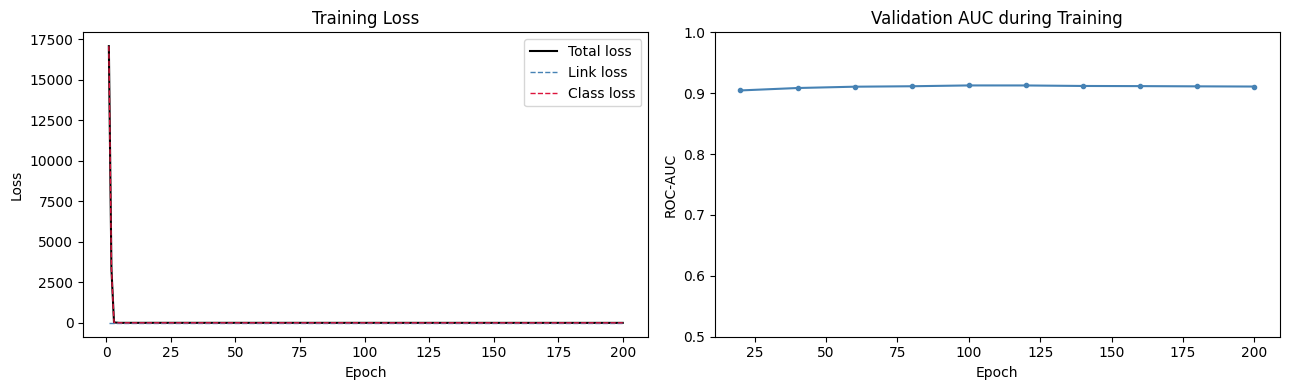

Val  — ROC-AUC: 0.9110 | AP: 0.5553 | F1: 0.4812 | Precision: 0.4121 | Recall: 0.5782 | Accuracy: 0.9122
Test — ROC-AUC: 0.8647 | AP: 0.2882 | F1: 0.3460 | Precision: 0.2635 | Recall: 0.5038 | Accuracy: 0.8999

 precision on val:


Best threshold (val F1): 0.6684
Val  @ thresh — F1: 0.5573 | Precision: 0.6691 | Recall: 0.4775
Test @ thresh — F1: 0.3885 | Precision: 0.3915 | Recall: 0.3855


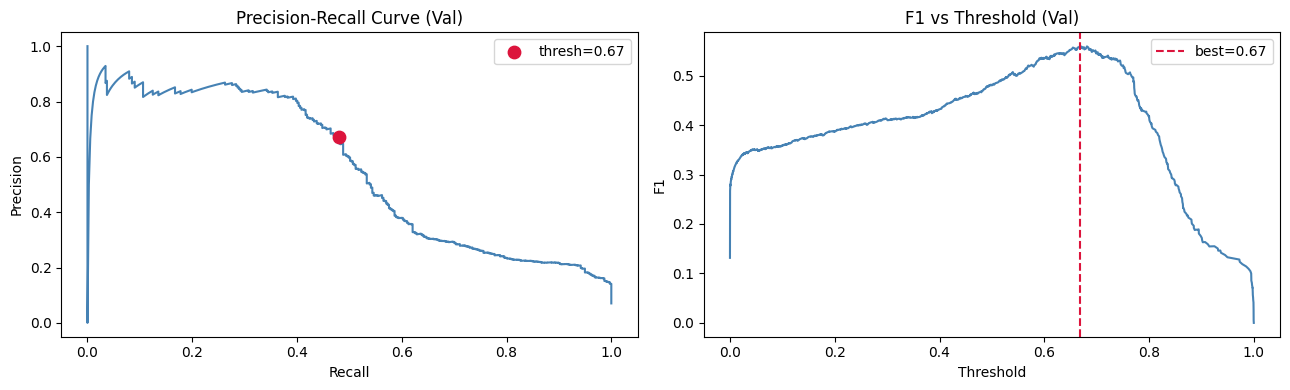


RecSys metrics @ k (Test):
k        P@k        R@k        NDCG@k    
--------------------------------------
50       0.2800     0.0267     0.2079    
100      0.4600     0.0878     0.3739    
200      0.5350     0.2042     0.4679    


In [23]:
# 2 tables
feature_cols = local_cols + agg_cols

model_dt, val_s, test_s, best_thresh = mf_cf_torch(
    df, edges, feature_cols,
    k=128, shared_table=False,
    alpha=1.0, beta=1.0, n_epochs=200, lr=1e-3, 
)

NDCG increasing with k:                                                          

  A perfect model would have NDCG@50 ≥ NDCG@100 ≥ NDCG@200 (or flat), because all fraud would be front-loaded at the very top. Here the model shows the opposite direction — it improves as the list of k is widened.
                  
  This means: the model identifies a pool of suspicious transactions with moderate confidence, but doesn't sharply concentrate the most suspicious ones at rank 1–50. Fraud is spread across ranks 50–200 rather than clustered at the top.                           
                  
  This is directly consistent with the choice of threshold already observed: Best threshold ~0.33, not 0.5 — scores are compressed in a narrow range (0.30–0.45). The model distinguishes fraud from licit (AUC=0.87) but doesn't assign extreme confidence scores to the most obvious fraud cases                               
                                                                                            
  the CF signal identifies a suspicious subpopulation but lacks the discriminative sharpness to rank within it, a known limitation of embedding-based methods vs. directly optimized classifiers.
                                                                                            
  

--- single-table (k=32) ---
  Epoch  20: loss=4.1337 (link=0.6925, class=3.4412)
  Epoch  40: loss=2.8330 (link=0.6889, class=2.1441)
  Epoch  60: loss=2.4234 (link=0.6793, class=1.7440)
  Epoch  80: loss=1.9860 (link=0.6619, class=1.3241)
  Epoch 100: loss=1.8350 (link=0.6371, class=1.1979)
  Epoch 120: loss=1.7448 (link=0.6071, class=1.1377)
  Epoch 140: loss=1.6862 (link=0.5748, class=1.1114)
  Epoch 160: loss=1.8125 (link=0.5432, class=1.2693)
  Epoch 180: loss=3.2881 (link=0.5143, class=2.7739)
  Epoch 200: loss=1.7721 (link=0.4895, class=1.2826)


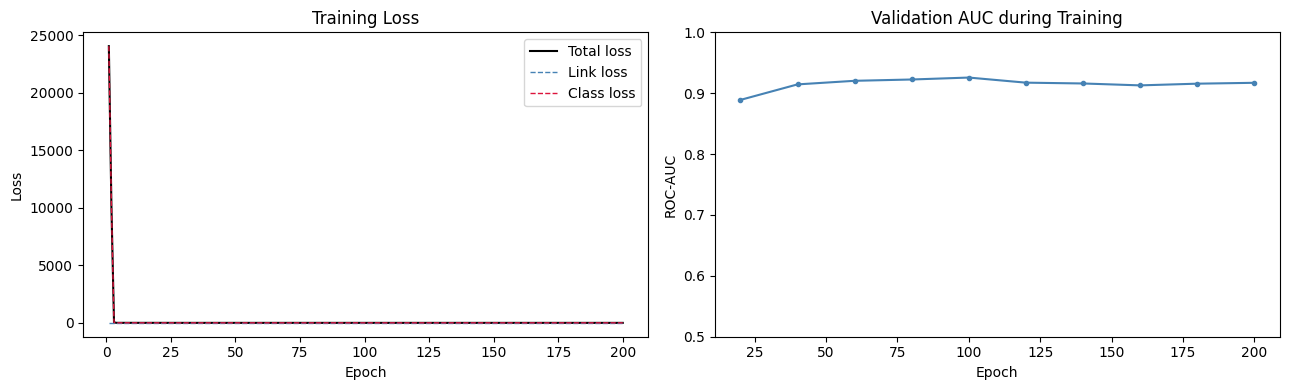

Val  — ROC-AUC: 0.9171 | AP: 0.5596 | F1: 0.4213 | Precision: 0.2971 | Recall: 0.7241 | Accuracy: 0.8600
Test — ROC-AUC: 0.8710 | AP: 0.3044 | F1: 0.2795 | Precision: 0.1778 | Recall: 0.6527 | Accuracy: 0.8232

 precision on val:


Best threshold (val F1): 0.8667
Val  @ thresh — F1: 0.5845 | Precision: 0.6857 | Recall: 0.5093
Test @ thresh — F1: 0.4031 | Precision: 0.4054 | Recall: 0.4008


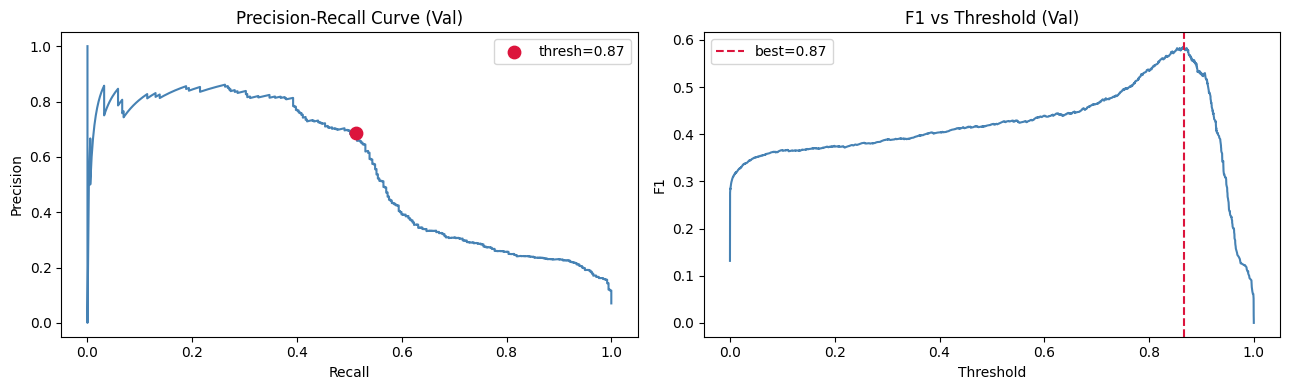


RecSys metrics @ k (Test):
k        P@k        R@k        NDCG@k    
--------------------------------------
50       0.2400     0.0229     0.1735    
100      0.4900     0.0935     0.3918    
200      0.5600     0.2137     0.4872    


In [24]:
# 1 table
model_dt, val_s, test_s, best_thresh = mf_cf_torch(
    df, edges, feature_cols,
    k=32, shared_table=True,
    alpha=1.0, beta=1.0, n_epochs=200, lr=1e-3
)

--- double-table (k=128) ---
  Epoch  20: loss=7.0542 (link=0.6907, class=6.3635)
  Epoch  40: loss=8.1514 (link=0.6776, class=7.4738)
  Epoch  60: loss=7.6967 (link=0.6438, class=7.0529)
  Epoch  80: loss=7.0262 (link=0.5901, class=6.4360)
  Epoch 100: loss=6.2087 (link=0.5300, class=5.6786)
  Epoch 120: loss=2.6260 (link=0.4785, class=2.1475)
  Epoch 140: loss=5.8039 (link=0.4413, class=5.3625)
  Epoch 160: loss=7.2013 (link=0.4162, class=6.7851)
  Epoch 180: loss=6.9906 (link=0.3994, class=6.5912)
  Epoch 200: loss=7.5199 (link=0.3876, class=7.1324)
  Epoch 220: loss=6.0006 (link=0.3784, class=5.6222)
  Epoch 240: loss=3.3654 (link=0.3705, class=2.9949)
  Epoch 260: loss=8.4619 (link=0.3636, class=8.0983)
  Epoch 280: loss=11.6496 (link=0.3558, class=11.2938)
  Epoch 300: loss=11.4253 (link=0.3487, class=11.0766)
  Epoch 320: loss=10.8149 (link=0.3395, class=10.4755)
  Epoch 340: loss=10.2952 (link=0.3300, class=9.9652)
  Epoch 360: loss=10.0058 (link=0.3178, class=9.6880)
  Epoch 3

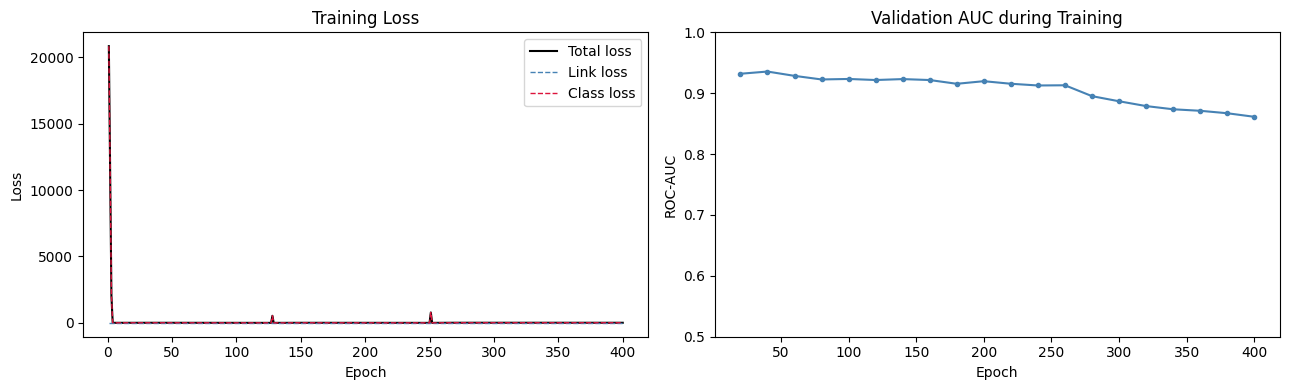

Val  — ROC-AUC: 0.8613 | AP: 0.2494 | F1: 0.3009 | Precision: 0.2450 | Recall: 0.3899 | Accuracy: 0.8725
Test — ROC-AUC: 0.7888 | AP: 0.1204 | F1: 0.1882 | Precision: 0.1310 | Recall: 0.3340 | Accuracy: 0.8486

 precision on val:


Best threshold (val F1): 0.0678
Val  @ thresh — F1: 0.3636 | Precision: 0.2528 | Recall: 0.6472
Test @ thresh — F1: 0.2553 | Precision: 0.1615 | Recall: 0.6088


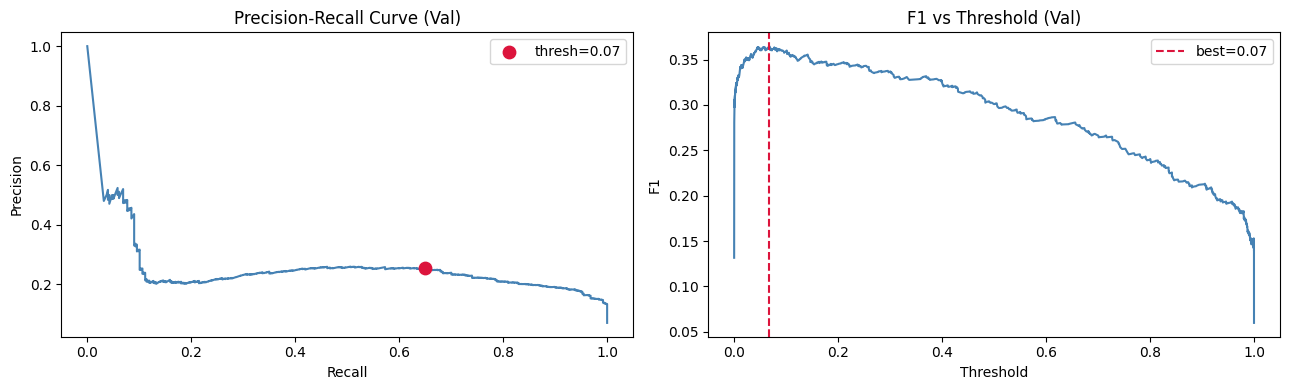


RecSys metrics @ k (Test):
k        P@k        R@k        NDCG@k    
--------------------------------------
50       0.1000     0.0095     0.0735    
100      0.0700     0.0134     0.0714    
200      0.0650     0.0248     0.0660    


In [25]:
# 2 tables with class weights
feature_cols = local_cols + agg_cols

model_dt, val_s, test_s, best_thresh = mf_cf_torch(
    df, edges, feature_cols,
    k=128, shared_table=False,pos_weight=True,
    alpha=1.0, beta=1.0, n_epochs=400, lr=1e-3
)

--- double-table (k=64) ---
  Epoch  20: loss=2.3731 (link=0.6919, class=1.6812)
  Epoch  40: loss=2.1628 (link=0.6852, class=1.4776)
  Epoch  60: loss=1.7184 (link=0.6670, class=1.0514)
  Epoch  80: loss=1.0522 (link=0.6347, class=0.4175)
  Epoch 100: loss=1.0139 (link=0.5916, class=0.4223)
  Epoch 120: loss=0.9932 (link=0.5452, class=0.4480)
  Epoch 140: loss=0.9297 (link=0.5027, class=0.4270)
  Epoch 160: loss=0.8671 (link=0.4680, class=0.3991)
  Epoch 180: loss=0.8147 (link=0.4414, class=0.3733)
  Epoch 200: loss=0.7721 (link=0.4222, class=0.3499)
  Epoch 220: loss=0.7358 (link=0.4077, class=0.3281)
  Epoch 240: loss=1.5226 (link=0.3973, class=1.1252)
  Epoch 260: loss=1.1189 (link=0.3892, class=0.7298)
  Epoch 280: loss=0.9056 (link=0.3824, class=0.5231)
  Epoch 300: loss=0.8709 (link=0.3770, class=0.4939)
  Epoch 320: loss=0.8358 (link=0.3724, class=0.4635)
  Epoch 340: loss=0.8063 (link=0.3683, class=0.4380)
  Epoch 360: loss=0.7800 (link=0.3645, class=0.4155)
  Epoch 380: loss=

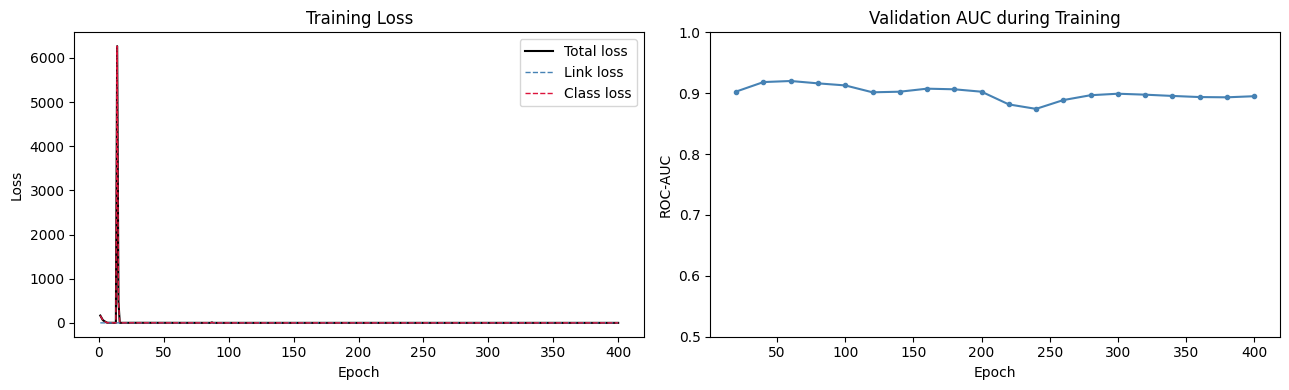

Val  — ROC-AUC: 0.8951 | AP: 0.3101 | F1: 0.4279 | Precision: 0.3272 | Recall: 0.6180 | Accuracy: 0.8837
Test — ROC-AUC: 0.8377 | AP: 0.1714 | F1: 0.3165 | Precision: 0.2213 | Recall: 0.5553 | Accuracy: 0.8740

 precision on val:


Best threshold (val F1): 0.5061
Val  @ thresh — F1: 0.4282 | Precision: 0.3291 | Recall: 0.6127
Test @ thresh — F1: 0.3185 | Precision: 0.2236 | Recall: 0.5534


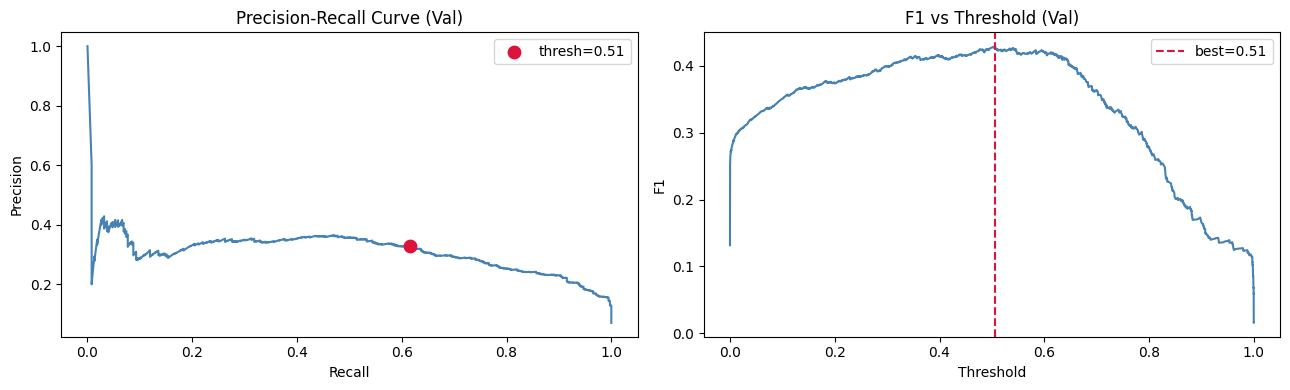


RecSys metrics @ k (Test):
k        P@k        R@k        NDCG@k    
--------------------------------------
50       0.0200     0.0019     0.0340    
100      0.0800     0.0153     0.0741    
200      0.0850     0.0324     0.0804    


In [26]:
# 2 tables with searching for best prediction threshold (not 0.5)

model_dt, val_s, test_s, best_thresh = mf_cf_torch(
    df, edges, feature_cols,
    k=64, shared_table=False,pos_weight=False,
    alpha=1.0, beta=1.0, n_epochs=400, lr=1e-3
)